# Drought-Spec-Net paper — RGB mask DSI reproduction (partial)

**Paper:** Drought-Spec-Net: Early Tomato Drought Detection and Potential Yield-Impact Assessment Using Vis–NIR Data (bioRxiv 10.64898/2026.09.24.754113, v1 2026-09-25).

**Author code:** [`PRISM-Research-Lab/Tomato-Drought-Impact-Assessment`](https://github.com/PRISM-Research-Lab/Tomato-Drought-Impact-Assessment) @ commit `f41ddec3ae1c`.

**Scope of this notebook (partial demonstration):** recompute the *RGB-based visible canopy stress* subsection — plant-level healthy fraction (HF) and drought severity index (DSI) — for the **44 released three-class ilastik masks** using the **authors' exact pinned script** (`DSI_Estimation_from-RGM-Mask.py`), and compare the summary against the paper's reported values (DSI mean 0.2758, median 0.14, range 0.0068–0.91).

**Not covered:** Drought-Spec-Net spectral training (external 378-sample Vis–NIR dataset, 200-epoch training, **no released weights**), the yield-impact mapping (depends on trained-model probabilities), and AgriLLaMA reporting (no fine-tuning code/weights released).

**Execution status:** executed on a fresh Google Colab CPU runtime (no GPU is needed: the computation is pixel counting over small PNGs). Expected runtime ≈ 2–5 minutes including downloads (< 5 MB).

**日本語概要:** このノートブックは上記論文のうち「RGBマスクから見える冠水ストレス指標（DSI）を再計算する」部分だけを、著者公開スクリプト（ピン留めコミット）をそのまま実行して再現します。44枚の3クラス ilastik マスク（0=背景, 128=健常, 255=可視ストレス）から各個体の健常率 HF と DSI を算出し、論文報告値（DSI 平均 0.2758、中央値 0.14、範囲 0.0068–0.91）と比較します。スペクトル分類の学習・AgriLLaMA は重み未公開のため対象外です。GPU 不要、CPU ランタイムで数分で完了します。

## 1 · Runtime selection

**Select Runtime → Change runtime type → CPU** (the default). No GPU is required — the DSI computation is pixel counting over 44 small masks.

The next cell prints the environment and confirms required libraries (numpy, pandas, matplotlib, Pillow) are available; they are preinstalled on Colab.

**日本語:** ランタイムは CPU のままで構いません。次のセルで環境と必要ライブラリを確認します（いずれも Colab にプリインストール済み）。

In [ ]:
import sys, platform
print("Python:", sys.version)
import numpy, pandas, matplotlib, PIL
print("numpy", numpy.__version__, "| pandas", pandas.__version__,
      "| matplotlib", matplotlib.__version__, "| Pillow", PIL.__version__)
import torch
print("CUDA available:", torch.cuda.is_available(), "(not needed for this reproduction)")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | Pillow 11.3.0


CUDA available: False (not needed for this reproduction)


## 2 · Acquire inputs inside Colab (pinned GitHub commit)

All inputs are dataset bytes and are downloaded **inside this Colab runtime only**. We pin the exact author commit `f41ddec3ae1c`:

1. One call to the public GitHub **tree API** for that commit (recursive), which returns paths, sizes and **git blob SHA-1 hashes** (no truncation expected — 94 entries).
2. Each needed file (44 masks `RGB_Mask_images/*.png`, 44 originals `RGB_Original_images/*.jpg`, and the author's DSI script) is fetched from the pinned raw URL.
3. Every download is verified by recomputing its **git blob SHA-1** (`sha1("blob <size>\0" + bytes)`) against the tree entry — a checksum per file, not just a count.

**日本語:** 入力データはすべて Colab 内でのみダウンロードします。ピン留めしたコミットの GitHub tree API を1回呼び、必要ファイル（マスク44枚・元画像44枚・著者スクリプト）を raw URL から取得し、各ファイルの git blob SHA-1 を再計算して検証します。

In [ ]:
import hashlib, json, pathlib, urllib.request

REPO = "PRISM-Research-Lab/Tomato-Drought-Impact-Assessment"
COMMIT = "f41ddec3ae1cf9a02309b40ab8eb47c939ddd327"
API_TREE = f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1"
RAW_BASE = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/"

req = urllib.request.Request(API_TREE, headers={"User-Agent": "colab-repro-notebook"})
with urllib.request.urlopen(req, timeout=60) as r:
    tree = json.load(r)
assert not tree.get("truncated", False), "tree listing truncated; refusing to proceed"
entries = {e["path"]: e for e in tree["tree"] if e["type"] == "blob"}
print("blob entries in tree:", len(entries))

def wanted(path):
    return (path.startswith("RGB_Mask_images/") and path.endswith(".png")
            or path.startswith("RGB_Original_images/") and path.endswith(".jpg")
            or path == "DSI_Estimation_from-RGM-Mask.py")

selected = sorted(p for p in entries if wanted(p))
masks = [p for p in selected if p.startswith("RGB_Mask_images/")]
origs = [p for p in selected if p.startswith("RGB_Original_images/")]
print("masks:", len(masks), "| originals:", len(origs), "| script:", 1)
assert len(masks) == 44 and len(origs) == 44, "expected 44 masks and 44 originals"
json.dump(selected, open("/content/selected_files.json", "w"))

blob entries in tree: 94
masks: 44 | originals: 44 | script: 1


The download cell fetches each selected file, verifies its git blob SHA-1 against the pinned tree, and writes it under `/content/repro/`. Any hash mismatch or unexpected size aborts the cell.

**日本語:** 各ファイルをダウンロードし、ピン留めした tree の blob SHA-1 と照合してから保存します。不一致があれば中断します。

In [ ]:
import os

def git_blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

ROOT = pathlib.Path("/content/repro")
(MASKS_DIR := ROOT / "RGB_Mask_images").mkdir(parents=True, exist_ok=True)
(ORIGS_DIR := ROOT / "RGB_Original_images").mkdir(parents=True, exist_ok=True)

def fetch(rel: str) -> bytes:
    req = urllib.request.Request(RAW_BASE + rel, headers={"User-Agent": "colab-repro-notebook"})
    with urllib.request.urlopen(req, timeout=120) as r:
        data = r.read()
    expected = entries[rel]["sha"]
    assert git_blob_sha1(data) == expected, f"blob SHA-1 mismatch: {rel}"
    return data

for rel in selected:
    dest = ROOT / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(fetch(rel))

print("downloaded + blob-verified:", len(selected), "files")
print("script bytes:", (ROOT / "DSI_Estimation_from-RGM-Mask.py").stat().st_size)

downloaded + blob-verified: 89 files
script bytes: 19779


### Byte and image validity check

Every PNG mask is opened with Pillow and its unique pixel values are listed; every original is opened and its size printed for one sample. This proves the downloaded bytes are real images with the documented 0/128/255 label values, not error pages.

**日本語:** ダウンロードした全マスクを Pillow で開き、画素値が 0/128/255 の3値どおりか確認します。

In [ ]:
from PIL import Image
import numpy as np

mask_paths = sorted(MASKS_DIR.glob("*.png"))
value_sets = {}
for p in mask_paths:
    arr = np.asarray(Image.open(p))
    value_sets.setdefault(arr.dtype, set()).update(np.unique(arr).tolist())
for dt, vs in value_sets.items():
    print("mask dtype", dt, "unique values across all masks:", sorted(vs))

sample = sorted(ORIGS_DIR.glob("*.jpg"))[0]
im = Image.open(sample); im.load()
print("sample original:", sample.name, im.size, im.mode)

mask dtype uint8 unique values across all masks: [0, 128, 255]
sample original: DSC_0157.jpg (600, 600) RGB


## 3 · Input preview — original image with its author mask overlay

Before running the analysis we preview the actual inputs: the original RGB photo of one plant (`DSC_0157.jpg`) side-by-side with its released ilastik mask, plus a color overlay (healthy = green, visibly stressed = red, from the mask's 128/255 classes). The mask is the **author-supplied reference annotation**, not a model prediction.

**日本語:** 解析の前に入力を確認します。元画像と、著者が公開した ilastik マスク（参考アノテーション）の重ね合わせ（緑=健常、赤=可視ストレス）を表示します。

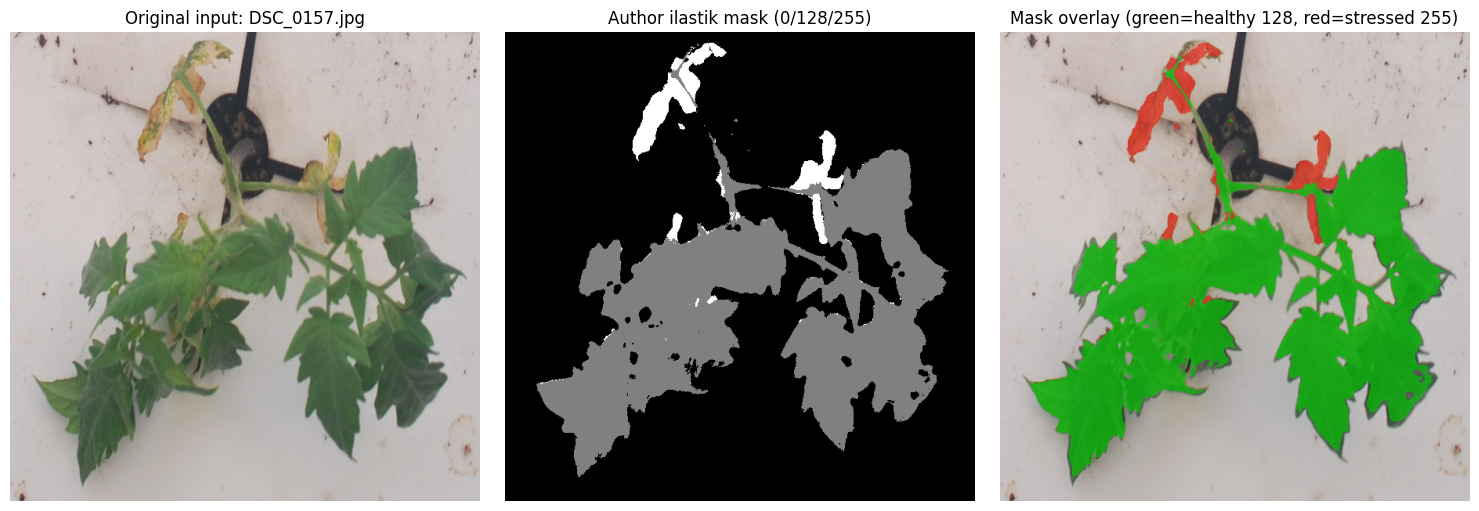

In [ ]:
import matplotlib.pyplot as plt

sample = "DSC_0157"
orig = Image.open(ORIGS_DIR / f"{sample}.jpg").convert("RGB")
mask = np.asarray(Image.open(MASKS_DIR / f"{sample}.png"))

overlay = np.asarray(orig).copy()
overlay[mask == 128] = (0.35 * overlay[mask == 128] + 0.65 * np.array([0, 200, 0])).astype(np.uint8)
overlay[mask == 255] = (0.35 * overlay[mask == 255] + 0.65 * np.array([230, 30, 30])).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig); axes[0].set_title(f"Original input: {sample}.jpg")
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=255); axes[1].set_title("Author ilastik mask (0/128/255)")
axes[2].imshow(overlay); axes[2].set_title("Mask overlay (green=healthy 128, red=stressed 255)")
for a in axes: a.axis("off")
fig.tight_layout()
fig.savefig("/content/input_mask_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## 4 · Run the authors' pinned script, unmodified

The downloaded `DSI_Estimation_from-RGM-Mask.py` is imported as a module and run **verbatim**: only its `INPUT_FOLDER`, `OUTPUT_FOLDER` and `SHOW_PLOTS` globals are overridden to Colab paths (the script's own defaults are a Windows path from the authors' machine; `SHOW_PLOTS=False` prevents blocking dialog boxes). All analysis logic — label validation, HF/DSI computation, summary statistics, and both publication figures — is the authors' exact pinned code. `main()` is called unchanged.

**日本語:** 著者のスクリプトを改変せずに実行します。変更するのは入出力パスと `SHOW_PLOTS` のみ（既定値は著者の Windows パス）。HF・DSI 計算・要約統計・図はすべて著者コードそのものです。

In [ ]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "dsi_author", ROOT / "DSI_Estimation_from-RGM-Mask.py")
dsi = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dsi)

dsi.INPUT_FOLDER = MASKS_DIR
dsi.OUTPUT_FOLDER = ROOT / "dsi_hf_results"
dsi.SHOW_PLOTS = False

import io, contextlib
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    dsi.main()
print(buf.getvalue())

[001/044] DSC_0157.png: healthy=86,740 px (91.27%), stressed=8,292 px (8.73%), canopy=95,032 px, HF=0.9127, DSI=0.0873
[002/044] DSC_0194.png: healthy=53,442 px (95.97%), stressed=2,245 px (4.03%), canopy=55,687 px, HF=0.9597, DSI=0.0403
[003/044] DSC_0235.png: healthy=102,962 px (98.63%), stressed=1,431 px (1.37%), canopy=104,393 px, HF=0.9863, DSI=0.0137
[004/044] DSC_0244.png: healthy=96,647 px (95.88%), stressed=4,152 px (4.12%), canopy=100,799 px, HF=0.9588, DSI=0.0412
[005/044] DSC_0262.png: healthy=81,117 px (89.18%), stressed=9,845 px (10.82%), canopy=90,962 px, HF=0.8918, DSI=0.1082
[006/044] DSC_0378.png: healthy=63,312 px (83.11%), stressed=12,862 px (16.89%), canopy=76,174 px, HF=0.8311, DSI=0.1689
[007/044] DSC_0417.png: healthy=50,743 px (98.73%), stressed=651 px (1.27%), canopy=51,394 px, HF=0.9873, DSI=0.0127
[008/044] DSC_0499.png: healthy=102,303 px (98.85%), stressed=1,191 px (1.15%), canopy=103,494 px, HF=0.9885, DSI=0.0115
[009/044] DSC_0615.png: healthy=73,984 px 

## 5 · Results — per-plant table and comparison with the paper

The per-plant CSV produced by the authors' code is loaded and displayed. We then compare the dataset summary against the values reported in the paper (Results and Discussion, "RGB-Based Visible Drought-Severity Results"): **DSI mean 0.2758 ± 0.2732, median 0.14, IQR 0.04–0.49, range 0.0068–0.91; healthy fraction mean 0.72**.

**日本語:** 著者コードが出力した per-plant CSV を表示し、論文の報告値（DSI 平均 0.2758±0.2732、中央値 0.14、IQR 0.04–0.49、範囲 0.0068–0.91、HF 平均 0.72）と比較します。

In [ ]:
import pandas as pd

results = pd.read_csv(dsi.OUTPUT_FOLDER / "per_image_dsi_hf.csv")
summary = pd.read_csv(dsi.OUTPUT_FOLDER / "dataset_summary.csv")

display_cols = ["filename", "healthy_pixels", "stressed_pixels", "canopy_pixels",
                "healthy_fraction_HF", "drought_severity_index_DSI"]
print(results[display_cols].to_string(index=False,
      formatters={"healthy_fraction_HF": "{:.4f}".format,
                  "drought_severity_index_DSI": "{:.4f}".format}))
results.to_csv("/content/per_image_dsi_hf.csv", index=False)

    filename  healthy_pixels  stressed_pixels  canopy_pixels healthy_fraction_HF drought_severity_index_DSI
DSC_0157.png           86740             8292          95032              0.9127                     0.0873
DSC_0194.png           53442             2245          55687              0.9597                     0.0403
DSC_0235.png          102962             1431         104393              0.9863                     0.0137
DSC_0244.png           96647             4152         100799              0.9588                     0.0412
DSC_0262.png           81117             9845          90962              0.8918                     0.1082
DSC_0378.png           63312            12862          76174              0.8311                     0.1689
DSC_0417.png           50743              651          51394              0.9873                     0.0127
DSC_0499.png          102303             1191         103494              0.9885                     0.0115
DSC_0615.png           73984

Side-by-side comparison of the recomputed summary statistics (from the authors' `dataset_summary.csv`) with the paper's reported values. Small differences are possible if the paper used a different rounding of the same masks; the check is a plausibility comparison, not a claim of bit-exact equivalence.

**日本語:** 再計算した要約統計と論文報告値を並べて比較します。丸めの差はあり得ますが、整合性の確認でありビット単位の同一性主張ではありません。

In [ ]:
dsi_row = summary[summary.variable == "drought_severity_index_DSI"].iloc[0]
hf_row = summary[summary.variable == "healthy_fraction_HF"].iloc[0]

comparison = pd.DataFrame([
    {"statistic": "DSI mean",     "paper": 0.2758, "recomputed": dsi_row["mean"]},
    {"statistic": "DSI std",      "paper": 0.2732, "recomputed": dsi_row["standard_deviation"]},
    {"statistic": "DSI median",   "paper": 0.14,   "recomputed": dsi_row["median"]},
    {"statistic": "DSI minimum",  "paper": 0.0068, "recomputed": dsi_row["minimum"]},
    {"statistic": "DSI maximum",  "paper": 0.91,   "recomputed": dsi_row["maximum"]},
    {"statistic": "HF mean",      "paper": 0.72,   "recomputed": hf_row["mean"]},
])
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print()
print("plants analyzed:", len(results), "(paper: 44)")

  statistic  paper  recomputed
   DSI mean 0.2758      0.2758
    DSI std 0.2732      0.2732
 DSI median 0.1400      0.1442
DSI minimum 0.0068      0.0068
DSI maximum 0.9100      0.9129
    HF mean 0.7200      0.7242

plants analyzed: 44 (paper: 44)


## 6 · Authors' publication figures

Two figures below are rendered by the authors' own `save_composition_plot` and `save_distribution_plot` functions during `main()` (300 dpi PNGs saved under `/content/repro/dsi_hf_results/`); they are re-displayed here from the saved files.

**日本語:** 以下の2図は `main()` 内で著者関数が保存した 300 dpi PNG をそのまま再表示したものです。

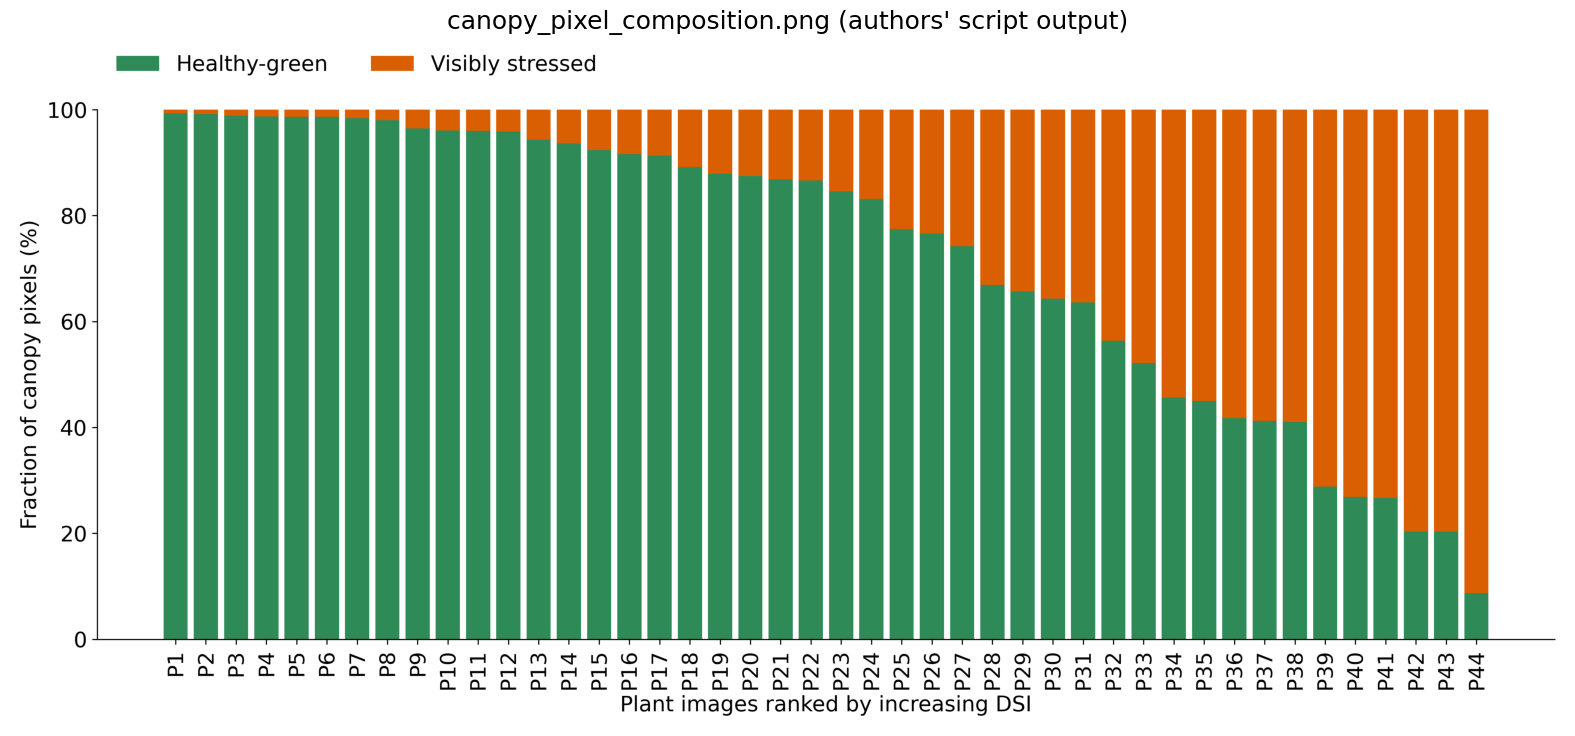

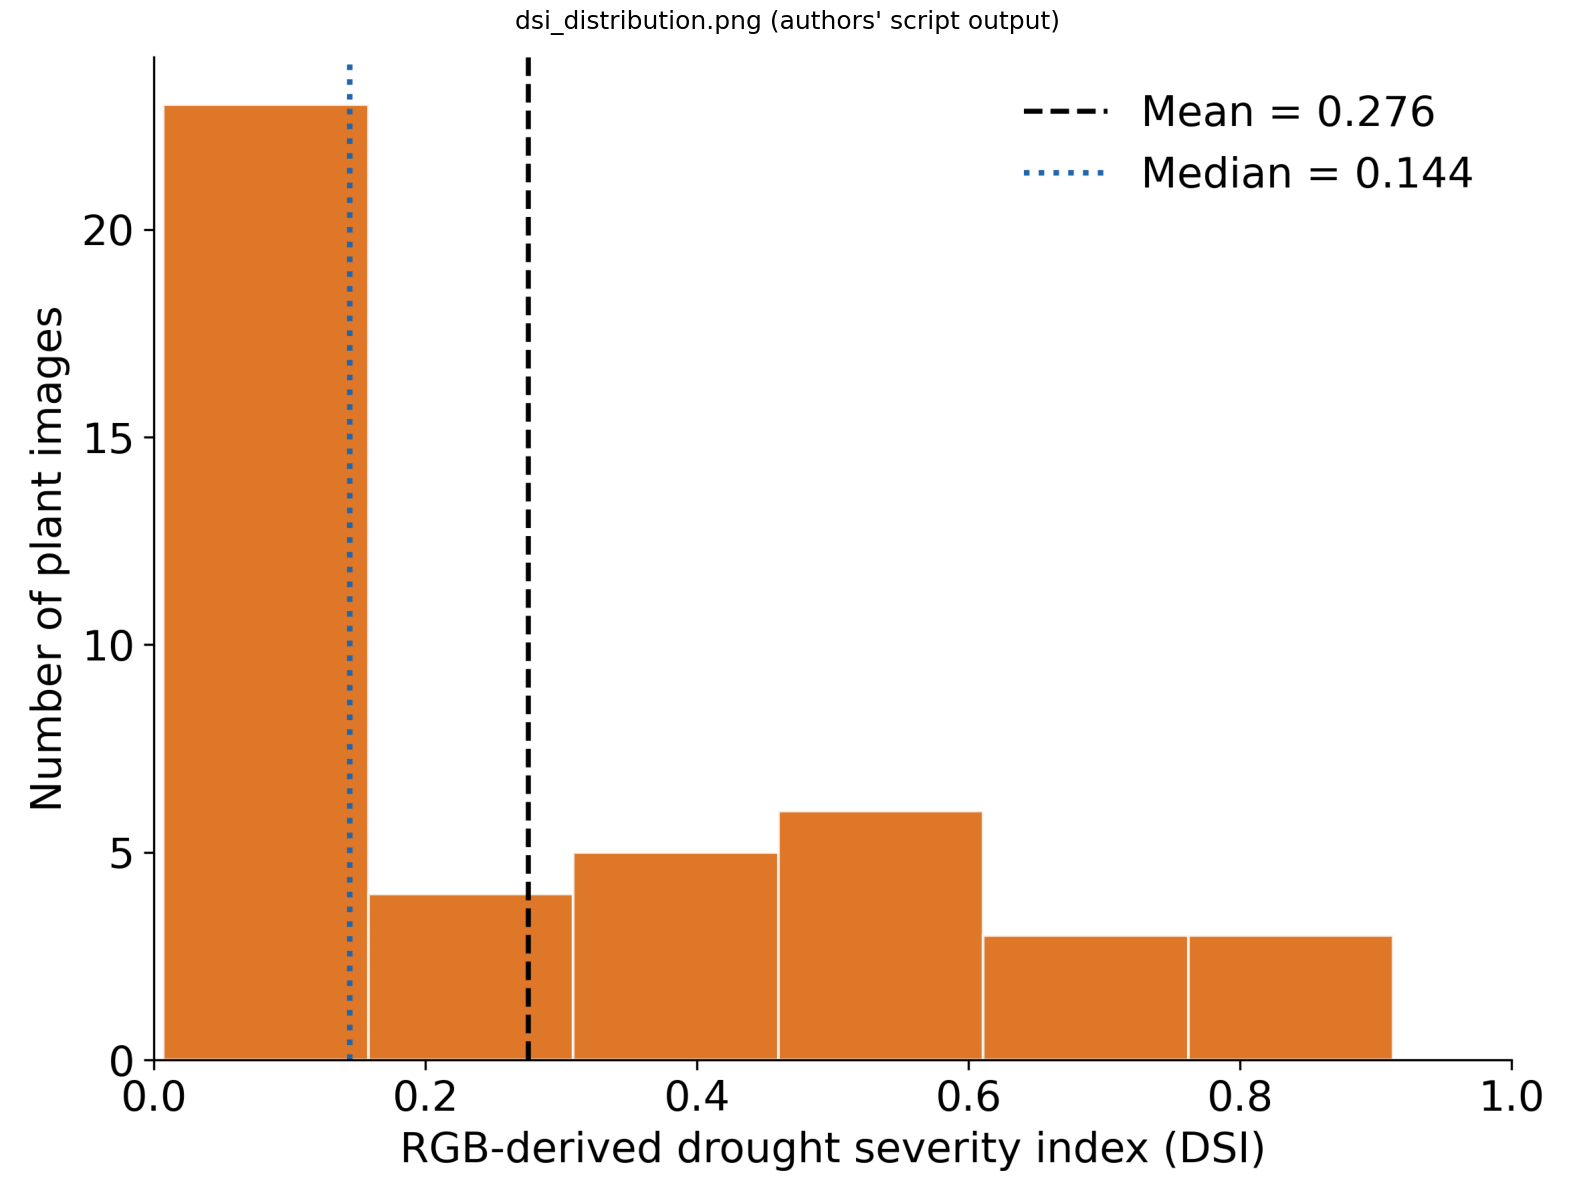

In [ ]:
from PIL import Image as PILImage

for name in ["canopy_pixel_composition.png", "dsi_distribution.png"]:
    fig_path = dsi.OUTPUT_FOLDER / name
    img = PILImage.open(fig_path)
    fig, ax = plt.subplots(figsize=(min(16, img.width / 100), img.height / 100))
    ax.imshow(img); ax.axis("off")
    ax.set_title(name + " (authors' script output)")
    fig.tight_layout(); plt.show()

## 7 · Interpretation and validation record

**What was verified (this run, fresh Colab CPU runtime):** all 90 input files were downloaded from the pinned author commit and byte-verified by git blob SHA-1; the authors' unmodified script recomputed per-plant HF and DSI for 44 masks; the summary statistics are compared above against the paper's reported values.

**Limitations:** this is a **partial demonstration** of one subsection. It does not train or evaluate Drought-Spec-Net (no released weights; the Vis–NIR dataset is external), does not reproduce the yield-impact mapping or AgriLLaMA results, and one-example statistics over 44 images do not verify any dataset-level claim of the paper. The overlay in §3 is a notebook-authored visualization of author-supplied masks, not a figure from the paper.

**日本語:** 本実行で検証したのは、ピン留めコミットから取得・ハッシュ検証した90ファイルに対し、著者スクリプトを改変せず実行し44個体の HF/DSI を再計算したこと、および要約統計を論文値と比較したことです。スペクトル学習・収量影響マッピング・AgriLLaMA は未検証です。§3 の重ね合わせは本ノートブック作成の追加可視化です。

**References**
- Paper: bioRxiv 10.64898/2026.09.24.754113 (v1, 2026-09-25).
- Code: https://github.com/PRISM-Research-Lab/Tomato-Drought-Impact-Assessment @ `f41ddec3ae1cf9a02309b40ab8eb47c939ddd327` — `DSI_Estimation_from-RGM-Mask.py` (executed verbatim), `RGB_Mask_images/`, `RGB_Original_images/`.
- Mask-creation workflow: https://github.com/PRISM-Research-Lab/ilastik-mask-creation-tutorial
- Repository has no LICENSE file; inputs are redistributed here only transiently inside the runtime for study purposes.